Using device: cuda
GPU: NVIDIA GeForce RTX 3070
Loading dataset...


Resolving data files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/45 [00:00<?, ?it/s]

Total images: 81444
Train: 57010 | Val: 12217 | Test: 12217


C:\Users\yimin\AppData\Local\Temp\ipykernel_21020\476181480.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\yimin\AppData\Local\Temp\ipykernel_21020\476181480.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `wei

...

Epoch 3: Train Loss=0.9895, Train Acc=0.6419 | Val Loss=1.2532, Val Acc=0.5615
Checkpoint saved at epoch 3


Epoch 4/5 [Val]: 100%|███████████████████████████████████████████████████████████████| 764/764 [05:38<00:00,  2.26it/s]


Epoch 4: Train Loss=0.8041, Train Acc=0.7152 | Val Loss=1.3186, Val Acc=0.5534
Checkpoint saved at epoch 4


Epoch 5/5 [Val]: 100%|███████████████████████████████████████████████████████████████| 764/764 [05:40<00:00,  2.24it/s]


Epoch 5: Train Loss=0.7491, Train Acc=0.7354 | Val Loss=1.2654, Val Acc=0.5784
Checkpoint saved at epoch 5
Final model and history saved!


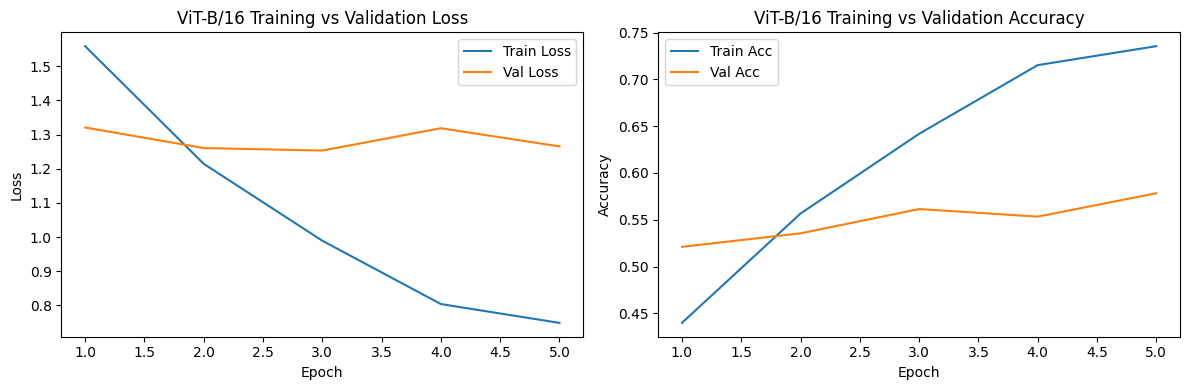

All done!


In [1]:
import sys
sys.path.append("E:\\wikiart_project")

from config import (
    set_seed, get_split_indices, get_transforms,
    WikiArtDataset, NUM_EPOCHS, LEARNING_RATE,
    LOSS_WEIGHTS, NUM_STYLES, NUM_GENRES, SAVE_DIR
)

import os
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from tqdm import tqdm
import timm
import matplotlib.pyplot as plt

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

print("Loading dataset...")
dataset = load_dataset("huggan/wikiart", split="train")
print(f"Total images: {len(dataset)}")

splits = get_split_indices(len(dataset))
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

IMAGE_SIZE = 224
BATCH_SIZE = 16
MODEL_NAME = "vit_base_patch16_224"

train_transform, eval_transform = get_transforms(IMAGE_SIZE)

train_dataset = WikiArtDataset(dataset, splits['train'], train_transform)
val_dataset   = WikiArtDataset(dataset, splits['val'],   eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class MultiTaskViT(nn.Module):
    def __init__(self, num_styles=NUM_STYLES, num_genres=NUM_GENRES):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        num_features = self.backbone.num_features
        self.style_head = nn.Linear(num_features, num_styles)
        self.genre_head = nn.Linear(num_features, num_genres)

    def forward(self, x):
        features = self.backbone(x)
        return self.style_head(features), self.genre_head(features)

model = MultiTaskViT().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler()

CHECKPOINT_PATH = f"{SAVE_DIR}\\{MODEL_NAME}_checkpoint.pth"
start_epoch = 0
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

if os.path.exists(CHECKPOINT_PATH):
    print(f"Found checkpoint! Resuming...")
    checkpoint = torch.load(CHECKPOINT_PATH)
    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scaler.load_state_dict(checkpoint['scaler_state'])
    start_epoch = checkpoint['epoch'] + 1
    train_losses = checkpoint['train_losses']
    val_losses   = checkpoint['val_losses']
    train_accs   = checkpoint['train_accs']
    val_accs     = checkpoint['val_accs']
    print(f"Resumed from epoch {start_epoch}")
else:
    print("No checkpoint found, starting from scratch.")

print("Model ready!")

for epoch in range(start_epoch, NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, styles, genres in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, styles, genres = images.to(device), styles.to(device), genres.to(device)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            style_out, genre_out = model(images)
            loss = LOSS_WEIGHTS['style'] * criterion(style_out, styles) + \
                   LOSS_WEIGHTS['genre'] * criterion(genre_out, genres)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        correct      += (style_out.argmax(1) == styles).sum().item()
        total        += styles.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, styles, genres in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Val]"):
            images, styles, genres = images.to(device), styles.to(device), genres.to(device)
            with torch.cuda.amp.autocast():
                style_out, genre_out = model(images)
                loss = LOSS_WEIGHTS['style'] * criterion(style_out, styles) + \
                       LOSS_WEIGHTS['genre'] * criterion(genre_out, genres)
            val_loss    += loss.item()
            val_correct += (style_out.argmax(1) == styles).sum().item()
            val_total   += styles.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc  = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scaler_state': scaler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
    }, CHECKPOINT_PATH)
    print(f"Checkpoint saved at epoch {epoch+1}")

torch.save(model.state_dict(), f"{SAVE_DIR}\\{MODEL_NAME}_wikiart.pth")
history = {
    'train_losses': train_losses, 'val_losses': val_losses,
    'train_accs': train_accs, 'val_accs': val_accs,
}
with open(f"{SAVE_DIR}\\{MODEL_NAME}_history.json", "w") as f:
    json.dump(history, f)
print("Final model and history saved!")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
ax1.plot(range(1, len(val_losses)+1),   val_losses,   label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'ViT-B/16 Training vs Validation Loss')
ax1.legend()

ax2.plot(range(1, len(train_accs)+1), train_accs, label='Train Acc')
ax2.plot(range(1, len(val_accs)+1),   val_accs,   label='Val Acc')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title(f'ViT-B/16 Training vs Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}\\{MODEL_NAME}_training_curves.png', dpi=150)
plt.show()
print("All done!")